# Clasp Queens: random-configuration value distribution

This notebook analyzes 1,000 unique random configurations on every training instance. Quantile seed 0 is the deterministic median of the ACLib EPM; the other five seeds are reproducible stochastic draws. Keeping these axes separate prevents target stochasticity from being confused with variation across configurations or instances.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import display

CANDIDATES = [
    Path.cwd().resolve(),
    (Path.cwd() / 'experiments/aclib/clasp_queens_surrogate/06_sample').resolve(),
]
HERE = next((path for path in CANDIDATES if (path / 'results').exists()), CANDIDATES[0])
ACLIB_ROOT = next(
    path for path in [HERE.parents[1], (Path.cwd() / 'experiments/aclib').resolve()]
    if (path / 'random_sampling_analytics.py').exists()
)
if str(ACLIB_ROOT) not in sys.path:
    sys.path.insert(0, str(ACLIB_ROOT))

from random_sampling_analytics import *
results = load_sampling_results(HERE)
display(overview_table(results))

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/pyt

,configurations,training_instances,quantile_modes,median_seed,stochastic_draws,target_predictions,cutoff,PAR10_timeout_cost,configspace_seed
benchmark,,,,,,,,,
Clasp Queens,1000,484,6,0,5,2904000,300.0,3000.0,20260729


## 1. Distribution of configuration values

Histogram and empirical CDF: each observation is one configuration's mean PAR10 over all 484 training instances on the deterministic median surface. Logarithmic performance axes make both fast configurations and PAR10-heavy configurations visible.

,value
minimum,21.256157
q01,31.889813
q10,76.725814
q25,93.571396
median,109.908971
mean,120.715166
q75,128.323352
q90,142.623334
q99,525.723610
maximum,1457.031215


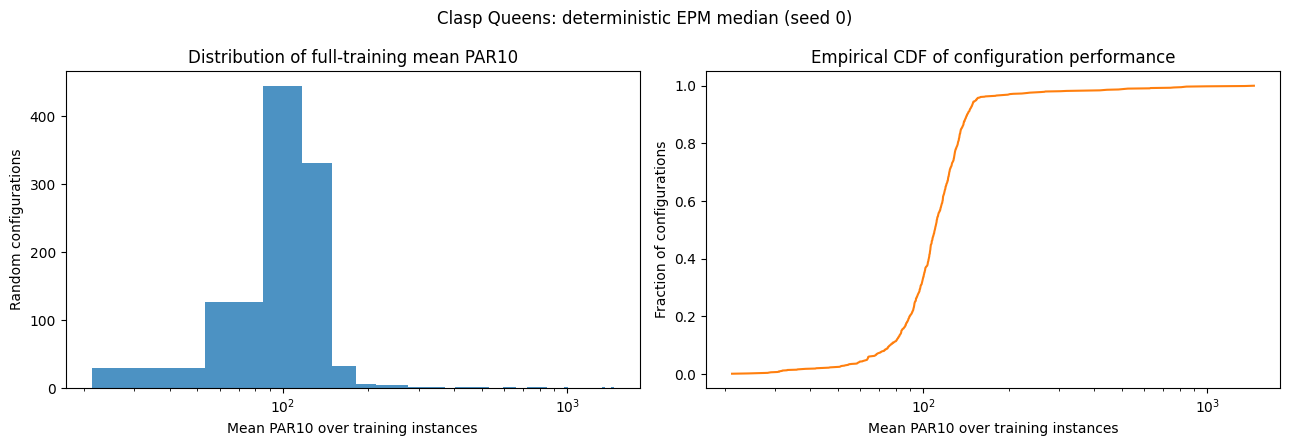

In [2]:
display(configuration_distribution_table(results))
plot_value_distribution(results)
plt.show()

Best/worst tables: the configurations are ranked by their full-training mean PAR10. The accompanying instance spread and timeout fraction show whether a good mean is broad or driven by a subset of instances.

In [3]:
best, worst = ranked_configurations(results, n=10)
print('Ten best sampled configurations')
display(best)
print('Ten worst sampled configurations')
display(worst)

Ten best sampled configurations


,configuration_index,mean_PAR10,median_instance_PAR10,instance_std,instance_IQR,timeout_fraction
0,356,21.256157,0.746635,49.715309,15.171778,0.000000
1,106,24.188790,0.528491,142.872851,12.128298,0.002066
2,369,25.870360,0.772028,194.605879,8.853489,0.004132
3,531,28.382170,1.097725,143.855200,21.145846,0.002066
4,647,28.681775,0.544874,194.434836,12.007848,0.004132
5,621,29.125830,5.250040,195.180685,16.627780,0.004132
6,834,30.667380,5.097260,195.631058,14.736627,0.004132
7,968,31.085235,4.451185,196.187822,18.074784,0.004132
8,516,31.105981,4.614480,195.896714,14.977186,0.004132
9,122,31.478713,1.037925,195.577110,17.751189,0.004132


Ten worst sampled configurations


,configuration_index,mean_PAR10,median_instance_PAR10,instance_std,instance_IQR,timeout_fraction
0,97,1457.031215,143.508270,1493.019127,2999.904289,0.483471
1,57,1353.629878,111.668785,1478.749510,2999.904349,0.446281
2,712,993.959007,1.692510,1397.427696,2999.719408,0.326446
3,124,843.046604,14.765041,1328.587413,2999.702985,0.274793
4,150,827.725686,47.451944,1310.462449,2999.903678,0.266529
5,809,807.775367,14.252540,1308.572444,2999.902648,0.262397
6,974,761.065935,16.322268,1272.928184,278.941676,0.243802
7,400,740.626314,2.048055,1262.971403,277.203569,0.237603
8,263,630.744697,1.867125,1180.664555,218.670705,0.198347
9,626,626.292080,2.833320,1189.883854,190.241828,0.200413


## 2. Variability across training instances

Scatter plot and histogram: every point is one configuration. The scatter compares its mean PAR10 with its standard deviation across instances; color is its timeout fraction. The second panel shows relative instance variability, so configurations at different performance scales can be compared.

,mean across configs,median,q90,maximum
instance standard deviation,469.773787,463.729251,546.541031,1493.019127
instance IQR,75.293293,59.434285,87.618138,2999.904349
coefficient of variation,4.235291,4.134420,5.087279,7.522349
timeout fraction,0.028432,0.024793,0.035124,0.483471


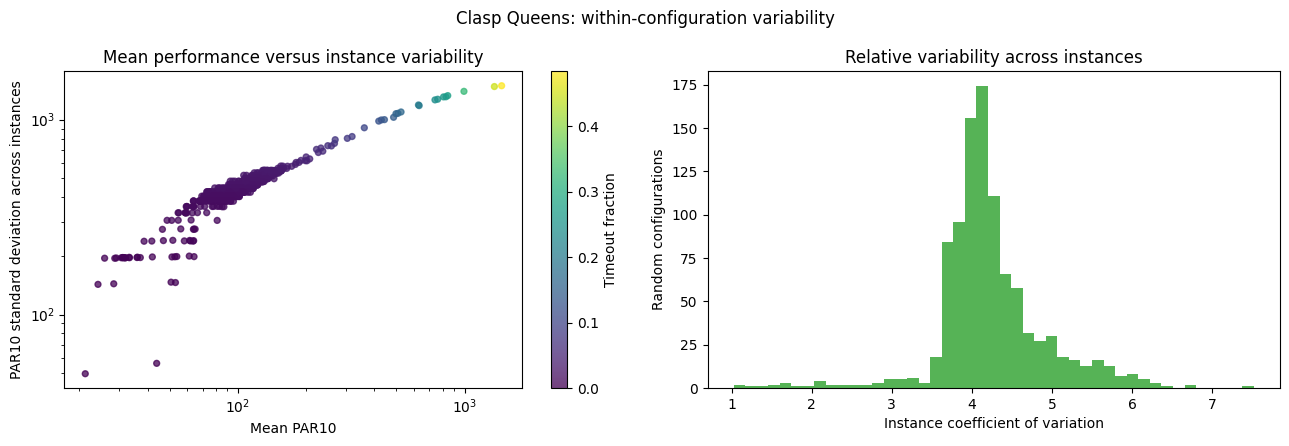

In [4]:
display(within_configuration_variability_table(results))
plot_instance_variability(results)
plt.show()

## 3. Variability of the stochastic target surrogate

Scatter plot and histogram: the left panel compares quantile seed 0 with the mean of five stochastic EPM draws for the same configuration and all training instances. The right panel measures draw-to-draw variability. A weak rank correlation would mean that fixing the target to its median materially changes the benchmark landscape.

,kind,mean_across_configurations,std_across_configurations,q10,median,q90
quantile_seed,,,,,,
0,median,120.715166,93.929832,76.725814,109.908971,142.623334
475207229,stochastic draw,46.745211,17.461771,25.607652,48.052369,66.002644
1792501355,stochastic draw,1087.228745,294.826900,737.207044,1070.727461,1553.475211
850460608,stochastic draw,810.482563,326.203434,414.403076,752.695878,1235.828087
1773604054,stochastic draw,105.293751,77.480597,66.931012,99.029875,130.633216
1755497032,stochastic draw,190.386502,173.375775,122.755736,148.439162,233.434226


,mean across configs,median,q90,maximum
full-training mean across stochastic draws,448.027354,424.639312,647.005820,1337.981100
per-config stochastic standard deviation,427.034812,411.300027,620.387608,781.154795
per-config stochastic coefficient of variation,0.961641,0.969772,1.040423,1.293803


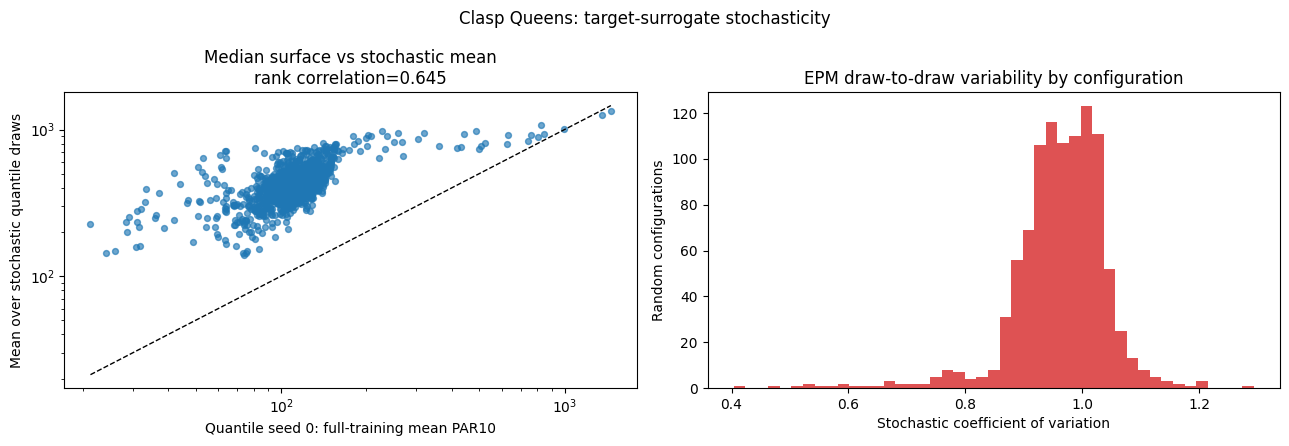

In [5]:
display(quantile_seed_table(results))
display(stochastic_variability_table(results))
plot_stochastic_variability(results)
plt.show()

## 4. Instance effects

Histogram and bar chart: instance difficulty is the mean PAR10 over all sampled configurations at quantile seed 0. The right panel identifies the 20 instances that dominate the high-cost tail.

,instance,mean_across_configurations,median_across_configurations,configuration_IQR,timeout_fraction
0,nqueen_48_1_0_0_0_pairwise.cnf,2986.273284,3000.000000,0.000000,0.995
1,nqueen_48_1_1_0_0_pairwise.cnf,2983.613736,3000.000000,0.000000,0.994
2,nqueen_36_1_1_0_0_pairwise.cnf,2909.783702,3000.000000,0.000000,0.967
3,nqueen_36_1_0_0_0_pairwise.cnf,2896.201836,3000.000000,0.000000,0.962
4,nqueen_36_1_1_0_0_2product.cnf,2868.923298,3000.000000,0.000000,0.952
5,nqueen_48_1_0_0_0_bimander.cnf,2838.519228,3000.000000,0.000000,0.941
6,nqueen_34_1_0_0_0_pairwise.cnf,2836.221534,3000.000000,0.000000,0.940
7,nqueen_48_1_1_0_0_bimander.cnf,2757.251338,3000.000000,0.000000,0.911
8,nqueen_33_1_1_0_0_commander.cnf,2712.638164,3000.000000,0.000000,0.895
9,nqueen_36_1_1_0_0_bimander.cnf,2437.484230,3000.000000,0.000000,0.794


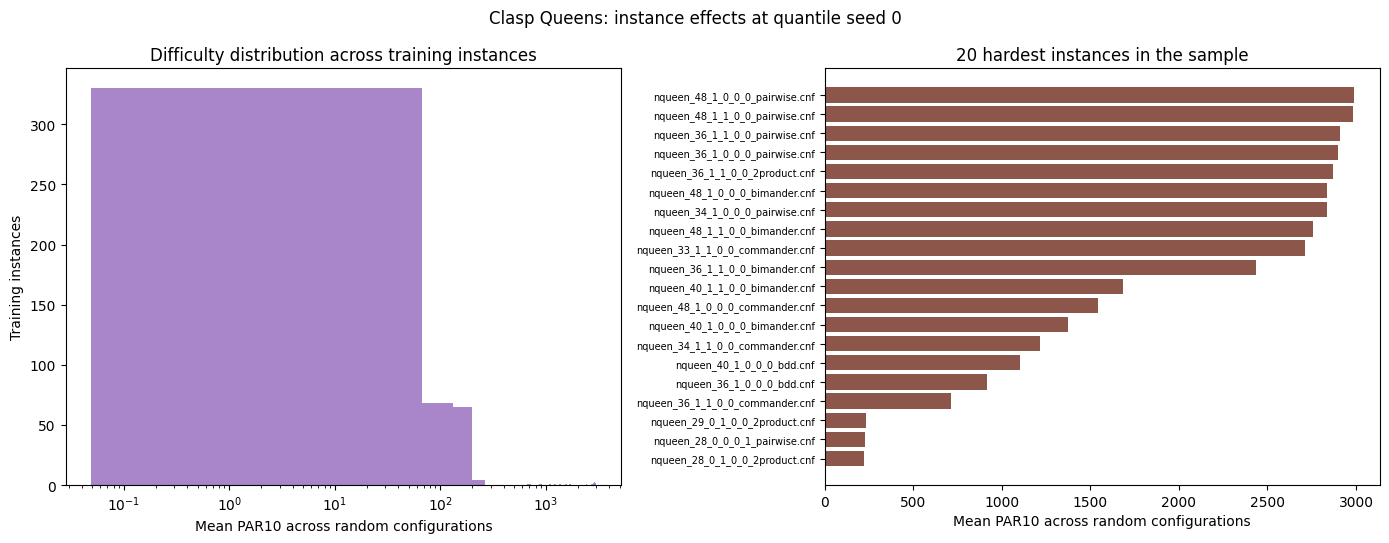

In [6]:
display(instance_table(results, n=15))
plot_instance_effects(results, n_hardest=20)
plt.show()

## 5. Sources of variation and sample stability

Variance table: these rows deliberately retain their stated aggregation level—between configurations, between instances within a configuration, and between stochastic EPM draws of full-training means. They diagnose scale, but should not be read as percentages of one classical ANOVA decomposition.

Convergence plot: the running best, median, and q10–q90 range show whether 1,000 random configurations are enough for stable distribution summaries.

,variance,measurement
source,,
between configurations,8822.813270,Variance of full-training mean PAR10
"within configuration, between instances",236896.031423,Mean per-configuration instance variance
"within configuration, between EPM draws",199836.110463,Mean per-configuration variance of full-traini...


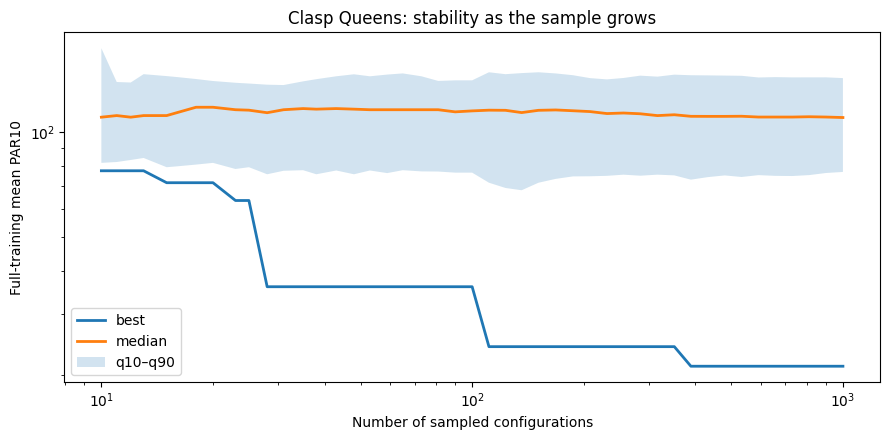

In [7]:
display(variance_decomposition(results))
plot_sampling_convergence(results)
plt.show()

## Interpretation guide

- A wide configuration distribution means the target distinguishes solver configurations strongly.
- Large within-configuration instance variation means adaptive intensification can produce optimistic early incumbents when coverage is small.
- Large stochastic draw variation or a weak median-versus-stochastic rank correlation means deterministic quantile seed 0 defines a meaningfully different optimization landscape from the official stochastic ACLib scenario.
- A stable median/q10/q90 with a still-improving running best means the distribution estimate is reliable even though more random samples could still find a better extreme.